In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def tridiagonal_matrix(x, y):
    
    n = len(x)
    h = np.diff(x)  # Step sizes between the data points
    
    
    # Initializing the matrix coefficients
    
    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector
    
    
    # Populate the tridiagonal matrix coefficients
    
    for i in range(1, n - 1):
        
        A[i - 1] = h[i-1]             # Subdiagonal
        B[i - 1] = 2 * (h[i-1] + h[i]) # Main diagonal
        C[i - 1] = h[i] # Superdiagonal
        D[i - 1] = 6 * ((y[i+1]-y[i])/h[i] - (y[i]-y[i-1])/h[i-1]) # Right-hand side vector
        
    return A, B, C, D

In [3]:

def thomas_algorithm(a, b, c, d):
    
    
    # Going to be solving the tridiagonal system using the Thomas algorithm.
    #a: sub-diagonal elements (length n-1)
    #b: main diagonal elements (length n)
    #c: super-diagonal elements (length n-1)
    #d: right-hand side (length n)
    #Is going to Return: solution vector x of length n
    
    n = len(b)
    
    
    # Forward elimination
    
    for i in range(1, n):
        
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
        
        
    # Back substitution
    
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
        
    return x

In [4]:
def cubic_spline(x, y):
    
    evalx = x
    evaly = y
    
    a, b, c, d = tridiagonal_matrix(x, y)
    M = np.array([0.0, * thomas_algorithm (a, b, c, d), 0.0], dtype=float)
    length = 0
    
    for i in range(len(x)-1):
        
        length = length + ((x[i+1]-x[i]) * 100)
        
    rety = np.zeros(length)
    retx = np.linspace(x[0], x[len(x)-1], length)
    
    print(len(rety))
    
    for i in range(len(x)-1):
        
        x_interp = np.arange(x[i], x[i+1], 0.01)
        h = x[i+1]-x[i]
        rety[i * 100:i * 100 + ((x[i+1]-x[i]) * 100)] = (M[i]/(6 * h)) * (x[i+1]-x_interp)**3 + \
        (M[i+1]/(6 * h)) * (x_interp-x[i])**3 + (y[i]/h - (M[i] * h)/6) * (x[i+1]-x_interp) + \
        (y[i+1]/h - (M[i+1] * h)/6) * (x_interp-x[i])
            
        
    return retx, rety

800


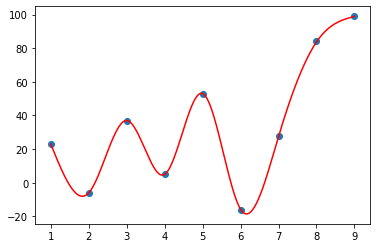

In [5]:
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9])
y = np.array([23, -6, 37, 5, 53, -16, 28, 84, 99])


xint, yint = cubic_spline(x, y)

plt.scatter(x, y) # Plotting the randomly selected data points
plt.plot(xint, yint, 'red') # Plotting the line itself
 

After running the code, It can be confidently said that there is a smooth cubic spline curve passing through the randomly selected data points. The spline will match the
data points exactly, with smooth transitions between them.